In [2]:
from fredapi import Fred
import yfinance as yf
import pandas_datareader.data as web

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import linregress
from itertools import product


In [ ]:
### Current Tickers ###
mineral_stocks = [
    'GC=F',  # Gold
    'HG=F',  # Copper
    'PA=F',  # Palladium
    'PL=F',  # Platinum
    'SI=F',  # Silver
]

growth_stocks = [
    "NVDA",  # NVIDIA Corporation
    "MRVL",  # Marvell Technology Inc.
    "FTNT",  # Fortinet Inc.
    "AMD",   # Advanced Micro Devices, Inc.
    "CRM",   # Salesforce Inc.
    "ADBE",  # Adobe Inc.
    "ZM",    # Zoom Video Communications Inc.
    "SHOP",  # Shopify Inc.
    "SNAP",  # Snap Inc.
    "NET",   # Cloudflare, Inc.
    "TWLO",  # Twilio Inc.
    "MDB",   # MongoDB, Inc.
    "RBLX",  # Roblox Corporation
    "SNOW",  # Snowflake Inc.
    "PINS",  # Pinterest Inc.
    "TTD",   # The Trade Desk
    "DOCU",  # DocuSign, Inc.
    'SLAB',  # Silicon Laboratories Inc.
]

value_stocks = [
    "AAPL",  # Apple Inc.
    "MSFT",  # Microsoft Corporation
    "INTC",  # Intel Corporation
    "IBM",   # International Business Machines Corporation
    "ORCL",  # Oracle Corporation
    "CSCO",  # Cisco Systems, Inc.
    "HPE",   # Hewlett Packard Enterprise Co.
    "QCOM",  # Qualcomm Incorporated
    "TXN",   # Texas Instruments Incorporated
    "AVGO",  # Broadcom Inc.
    "MU",    # Micron Technology Inc.
    "LRCX",  # Lam Research Corporation
    "STX",   # Seagate Technology Holdings PLC
    "WDC",   # Western Digital Corporation
    "ADI",   # Analog Devices, Inc.
    "AMAT",  # Applied Materials, Inc.
    "MSI",   # Motorola Solutions, Inc.
    "VZ",    # Verizon Communications Inc.
    "TMUS"   # T-Mobile US, Inc.
]

market_indices = [
    "^DJI",     # Dow Jones Industrial Average (United States)
    "^GSPC",    # S&P 500 (United States)
    "^IXIC",    # NASDAQ Composite (United States)
    "^N225",    # Nikkei 225 (Japan)
    "^FTSE",    # FTSE 100 (United Kingdom)
    "^GDAXI",   # DAX (Germany)
    "^FCHI",    # CAC 40 (France)
    "HSI",      # Hang Seng Index (Hong Kong)
    "000001.SS",# Shanghai Composite Index (China)
    "^BSESN",   # SENSEX (India)
    "^NSEI",    # Nifty 50 (India)
    "^KS11",    # KOSPI (South Korea)
    "^AORD",    # All Ordinaries (Australia)
    "^BVSP",    # Bovespa (Brazil)
    "^MERV",    # MERVAL (Argentina)
    "^TWII",    # TAIEX (Taiwan)
    "^STI",     # Straits Times Index (Singapore)
    "^JKSE",    # Jakarta Composite Index (Indonesia)
    
]


In [134]:
start_date = "2023-01-01"


### Download Mineral Data ###
minerals = yf.download(mineral_stocks,start=start_date,auto_adjust=True,progress=False)["Close"]
minerals = minerals.dropna()
# minerals.columns = [(x[1] +' '+ x[0]).strip() for x in minerals.columns.to_list()]



## Download Closing Price of Growth and Value Stocks in One DataFrame ###
all_stocks = growth_stocks + value_stocks
stock_data = yf.download(all_stocks, start=start_date, progress=False,auto_adjust=True)['Close']


In [206]:
def generate_pairs(commodities, stocks):
    """
    Create list of all possible (commodity, stock) pairs.
    
    Parameters:
        commodities: Input Dataframe of commodity closing prices with datetime index
        stocks: Input Dataframe of commodity closing prices with datetime index
    
    Returns:
        list: list of tuples of (commodity name, stock name)
    """
    return list(product(commodities.columns, stocks.columns))

def compute_features(commodity, stock, lag=0):
    """
    Operations:
        1. Calculates a lagged log returns of a commodity
        2. Calculates a log return of stock
        3. Calculates a 21-day rolling correlation between the commodity and the stock
        4. Calculates a 3-day gradient of the commodity.
    
    Parameters:
        commodity: Input Dataframe of commodity closing prices with datetime index
        stock: Input Dataframe of commodity closing prices with datetime index
        lag: Integer lag number
    
    Returns:
        pd.DataFrame: dataframe with stock, commodity log returns, rolling_corr, and 3-day gradient
    """
    

    commodity_name = commodity.name + f'_lag_{str(lag)}'
    stock_name = stock.name
    
    commodity_returns =  np.log(commodity).diff(1+lag)
    stock_returns = np.log(stock).diff(1)
    df = pd.DataFrame(
        {commodity_name: commodity_returns,
         stock_name: stock_returns
    }).dropna()
    df['rolling_corr'] = df[commodity_name].rolling(window=21).corr(df[stock_name])
    df['gradient'] = df[commodity_name].rolling(window=2).apply(lambda x: linregress(range(2), x).slope, raw=True)

    return df.dropna()

def detect_trade_signals(df, threshold=0.95, min_streak=3):
    """
    Operations:
        1. Identifies rolling correlation.
        2. Identifies streaks of outlier rolling correlations.
        3. Filters for top 50% absolute gradient values.
        4. Calucluates trade signals based on sign of the gradient.
    
    Parameters:
        df: Input Dataframe of commodity closing prices with datetime index
        thershold: int - threshold of rolling correlation
        min_streak: int - minimum number of consecutive days of correlations above threshold
    
    Returns:
        pd.DataFrame: dataframe with rolling_corr, gradient, and trade_signal
    """
    quantiles = df.rolling_corr.quantile([.1,.9]).values
    high = quantiles[1]
    low = quantiles[0]
    
    df['over_thresh'] = df['rolling_corr'].apply(lambda x: 1 if x > high or x < low  else 0)  


    
    df['streak'] = df['over_thresh'].astype(int).groupby(df['over_thresh'].ne(df['over_thresh'].shift()).cumsum()).cumsum()

    # Filter for streaks that meet min_streak requirement
    signal_df = df[(df['streak'] >= min_streak)]

    # Select top 90% of absolute gradient values
    cutoff = signal_df['gradient'].abs().quantile(0.95)
    signal_df = signal_df[signal_df['gradient'].abs() >= cutoff]
    # signal_df['trade_signal'] = signal_df['gradient'].apply(lambda x: 'long' if x > 0 else 'short')
    signal_df['trade_signal'] = signal_df.apply(
    lambda row: 'long' if (row['gradient'] > cutoff and row['rolling_corr'] > high and row['streak'] >= min_streak)
    else ('short' if row['gradient'] < -cutoff and row['rolling_corr'] < low and row['streak'] >= min_streak else 0),
    axis=1
    )

    return signal_df[signal_df.trade_signal != 0]



def print_signals(signals, commodity_name, stock_name, lag):
    """Prints trade signals in a readable format."""
    if not signals.empty:
        print(f"\n📢 Trade Signals for {commodity_name} (lag={lag}) & {stock_name}")
        print(signals[['rolling_corr', 'gradient', 'trade_signal']])

def main(commodities, stocks, threshold=0.95, min_streak=3, lag=1):
    """
        
    """

    # Generate pairs
    pairs = generate_pairs(commodities, stocks)

    # Process each pair
    for commodity, stock in pairs:
        # print(f"\n🔄 Processing {commodity} & {stock}...")
        df_features = compute_features(commodities[commodity], stocks[stock], lag=lag)
        trade_signals = detect_trade_signals(df_features, threshold=threshold, min_streak=min_streak)
        
        print_signals(trade_signals, commodity + f"_lag_{lag}", stock, lag=lag)


In [207]:

min_streak = 3


df_features = compute_features(minerals['SI=F'], stock_data['QCOM'], lag=5)

quantiles = df_features.rolling_corr.quantile([.1,.9]).values
high = quantiles[1]
print(high)
low = quantiles[0]
print(low)
df_features['over_thresh'] = df_features['rolling_corr'].apply(lambda x: 1 if x > high or x < low  else 0)
df_features['streak'] = df_features['over_thresh'].astype(int).groupby(df_features['over_thresh'].ne(df_features['over_thresh'].shift()).cumsum()).cumsum()

# # Select top 50% of absolute gradient values
cutoff = df_features[df_features['streak']>=min_streak]['gradient'].abs().quantile(0.9)
print(cutoff)



df_features['signal'] = df_features.apply(
    lambda row: 1 if row['gradient'] > cutoff and row['rolling_corr'] > high and row['streak'] >= min_streak
    else (-1 if row['gradient'] < -cutoff and row['rolling_corr'] < low and row['streak'] >= min_streak else 0),
    axis=1
)

df_features['positions'] = df_features['signal'].apply(lambda signal: 2 if signal  == 1 else -2 if signal == -1 else 0)



0.31432260011542146
-0.30132294452611413
0.04264162162926719


In [208]:
df_features[df_features.signal != 0]

,SI=F_lag_5,QCOM,rolling_corr,gradient,over_thresh,streak,signal,positions
Date,,,,,,,,
2023-04-04,0.081916,-0.019755,0.372269,0.052500,1,14,1,2
2023-11-07,-0.033810,0.006566,-0.413532,-0.050317,1,4,-1,-2
2023-12-22,0.008019,0.007345,-0.301754,-0.063071,1,8,-1,-2
2024-02-26,-0.017390,0.013592,-0.352926,-0.045560,1,15,-1,-2


In [121]:
import backtester
from backtester import Backtester
from backtester import Strategy

In [201]:
#### Run all pairs - pick the top ones

Final Portfolio Value: 9989.73
Total Return: -0.10%
Annualized Return: -0.05%
Annualized Volatility: 16.85%
Sharpe Ratio: -0.12
Sortino Ratio: -0.09
Maximum Drawdown: -20.16%


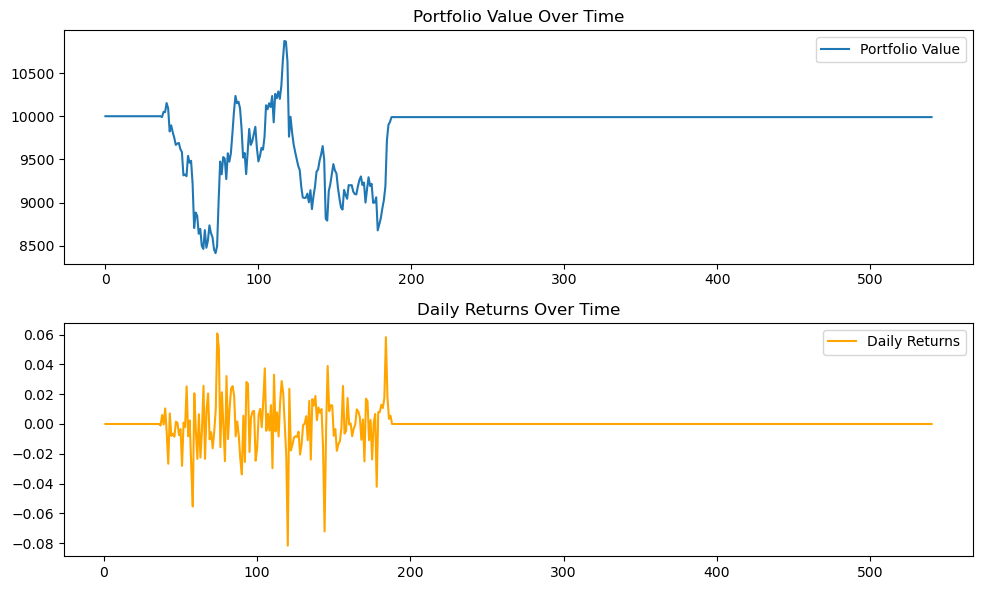

In [209]:
data = pd.concat([stock_data.loc[:,['QCOM']],df_features.iloc[:,-2:]],axis=1).dropna().rename(columns={'QCOM':'close'})
backtester = Backtester()
backtester.backtest(data)
backtester.calculate_performance()

In [197]:
for lag in range(0, 6):
    print(f"\n🚀 Running strategy with LAG = {lag}")
    main(minerals, stock_data, min_streak=3, lag=lag)


🚀 Running strategy with LAG = 0

📢 Trade Signals for GC=F_lag_0 (lag=0) & AAPL
            rolling_corr  gradient trade_signal
Date                                           
2023-11-10     -0.537759 -0.022705        short
2024-03-22     -0.512942 -0.022487        short
2024-08-23      0.516580  0.023660         long
2024-11-12      0.519835  0.024503         long

📢 Trade Signals for GC=F_lag_0 (lag=0) & ADBE
            rolling_corr  gradient trade_signal
Date                                           
2023-11-10     -0.510095 -0.022705        short
2024-01-16     -0.476138 -0.026122        short
2025-03-03      0.381032  0.034873         long

📢 Trade Signals for GC=F_lag_0 (lag=0) & ADI
            rolling_corr  gradient trade_signal
Date                                           
2023-11-10     -0.471392 -0.022705        short
2023-12-04     -0.265521 -0.038920        short
2024-08-23      0.453155  0.023660         long

📢 Trade Signals for GC=F_lag_0 (lag=0) & AMAT
            